In [6]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pydub import AudioSegment
from scipy.io import wavfile

# Ignorar advertencias de scipy
warnings.filterwarnings('ignore')

# Configuración de nombres de archivos (Rutas locales)
INPUT_AUDIO_PATH = "C1.mp3"      
OUTPUT_MP3_PATH  = "Cuerda1_libre.mp3"
OUTPUT_WAV_TEMP  = "audio_temp.wav"

if not os.path.exists(INPUT_AUDIO_PATH):
    print(f"❌ Error: No se encuentra '{INPUT_AUDIO_PATH}' en la carpeta actual.")
    print(f"Archivos presentes: {os.listdir('.')}")
else:
    print(f"✅ Archivo listo para procesar: '{INPUT_AUDIO_PATH}'")

✅ Archivo listo para procesar: 'C1.mp3'


In [10]:
# Cargar el archivo de audio original (pydub detecta el formato automáticamente)
print(f" Cargando '{INPUT_AUDIO_PATH}'...")
audio = AudioSegment.from_file(INPUT_AUDIO_PATH)

# Mostrar información del audio cargado
print(f"   ├─ Canales       : {audio.channels} ({'Mono' if audio.channels == 1 else 'Estéreo'})")
print(f"   ├─ Tasa de muestreo: {audio.frame_rate} Hz")
print(f"   ├─ Duración       : {len(audio) / 1000:.2f} segundos")
print(f"   └─ Bits por muestra: {audio.sample_width * 8} bits")

# Exportar a MP3
print(f"\n Exportando a MP3 → '{OUTPUT_MP3_PATH}'...")
audio.export(OUTPUT_MP3_PATH, format="mp3")
print(f" Archivo MP3 generado: '{OUTPUT_MP3_PATH}'")

# Exportar también a WAV para poder leer los datos crudos con scipy
audio.export(OUTPUT_WAV_TEMP, format="wav")
print(f" Archivo WAV temporal generado: '{OUTPUT_WAV_TEMP}'")

 Cargando 'C1.mp3'...
   ├─ Canales       : 1 (Mono)
   ├─ Tasa de muestreo: 48000 Hz
   ├─ Duración       : 1.60 segundos
   └─ Bits por muestra: 16 bits

 Exportando a MP3 → 'Cuerda1_libre.mp3'...
 Archivo MP3 generado: 'Cuerda1_libre.mp3'
 Archivo WAV temporal generado: 'audio_temp.wav'


In [11]:
# Leer el archivo WAV con scipy para obtener los datos crudos
sample_rate, data = wavfile.read(OUTPUT_WAV_TEMP)

print(f" Tasa de muestreo : {sample_rate} Hz")
print(f" Forma del array  : {data.shape}")
print(f" Tipo de dato     : {data.dtype}")

# Si es estéreo (2 columnas), convertir a mono promediando los canales
if data.ndim == 2:
    print(" Audio estéreo detectado → promediando canales para obtener mono")
    data = data.mean(axis=1)

# Normalizar la señal al rango [-1.0, 1.0]
# El factor de normalización depende del tipo de dato (8, 16 o 32 bits)
max_val = np.iinfo(data.dtype).max if np.issubdtype(data.dtype, np.integer) else 1.0
signal = data.astype(np.float64) / max_val

# Crear el eje de tiempo en segundos
duration = len(signal) / sample_rate
time_axis = np.linspace(0, duration, len(signal))

print(f"\n Señal lista:")
print(f"   ├─ Total de muestras : {len(signal):,}")
print(f"   ├─ Duración          : {duration:.3f} s")
print(f"   └─ Rango normalizado : [{signal.min():.3f}, {signal.max():.3f}]")

 Tasa de muestreo : 48000 Hz
 Forma del array  : (76723,)
 Tipo de dato     : int16

 Señal lista:
   ├─ Total de muestras : 76,723
   ├─ Duración          : 1.598 s
   └─ Rango normalizado : [-0.494, 0.396]


In [12]:
N = len(signal)  # Número total de muestras

# ── Aplicar ventana de Hann para reducir spectral leakage ──────────────────
window   = np.hanning(N)           # Ventana de Hann: suaviza los bordes de la señal
signal_w = signal * window         # Señal ventaneada

# ── Calcular la FFT ────────────────────────────────────────────────────────
fft_result = np.fft.fft(signal_w)  # Array de N números complejos

# ── Magnitud del espectro ──────────────────────────────────────────────────
# |X[k]| da la amplitud de cada componente de frecuencia
# Multiplicamos por 2/N para normalizar (y x2 por quedarnos con mitad)
magnitude = (2 / N) * np.abs(fft_result[:N // 2])

# ── Eje de frecuencias ─────────────────────────────────────────────────────
# fftfreq genera las frecuencias correspondientes a cada bin de la FFT
# d = 1/sample_rate es el intervalo de muestreo en segundos
frequencies = np.fft.fftfreq(N, d=1 / sample_rate)[:N // 2]

# ── Frecuencia dominante ───────────────────────────────────────────────────
idx_max   = np.argmax(magnitude)
freq_dom  = frequencies[idx_max]
mag_max   = magnitude[idx_max]

print(f" FFT calculada sobre {N:,} muestras")
print(f"   ├─ Resolución frecuencial : {sample_rate/N:.4f} Hz por bin")
print(f"   ├─ Frecuencia máxima repr.: {frequencies[-1]:.1f} Hz (Nyquist)")
print(f"   └─ Frecuencia dominante   : {freq_dom:.2f} Hz (magnitud {mag_max:.4f})")

 FFT calculada sobre 76,723 muestras
   ├─ Resolución frecuencial : 0.6256 Hz por bin
   ├─ Frecuencia máxima repr.: 23999.1 Hz (Nyquist)
   └─ Frecuencia dominante   : 330.33 Hz (magnitud 0.0364)


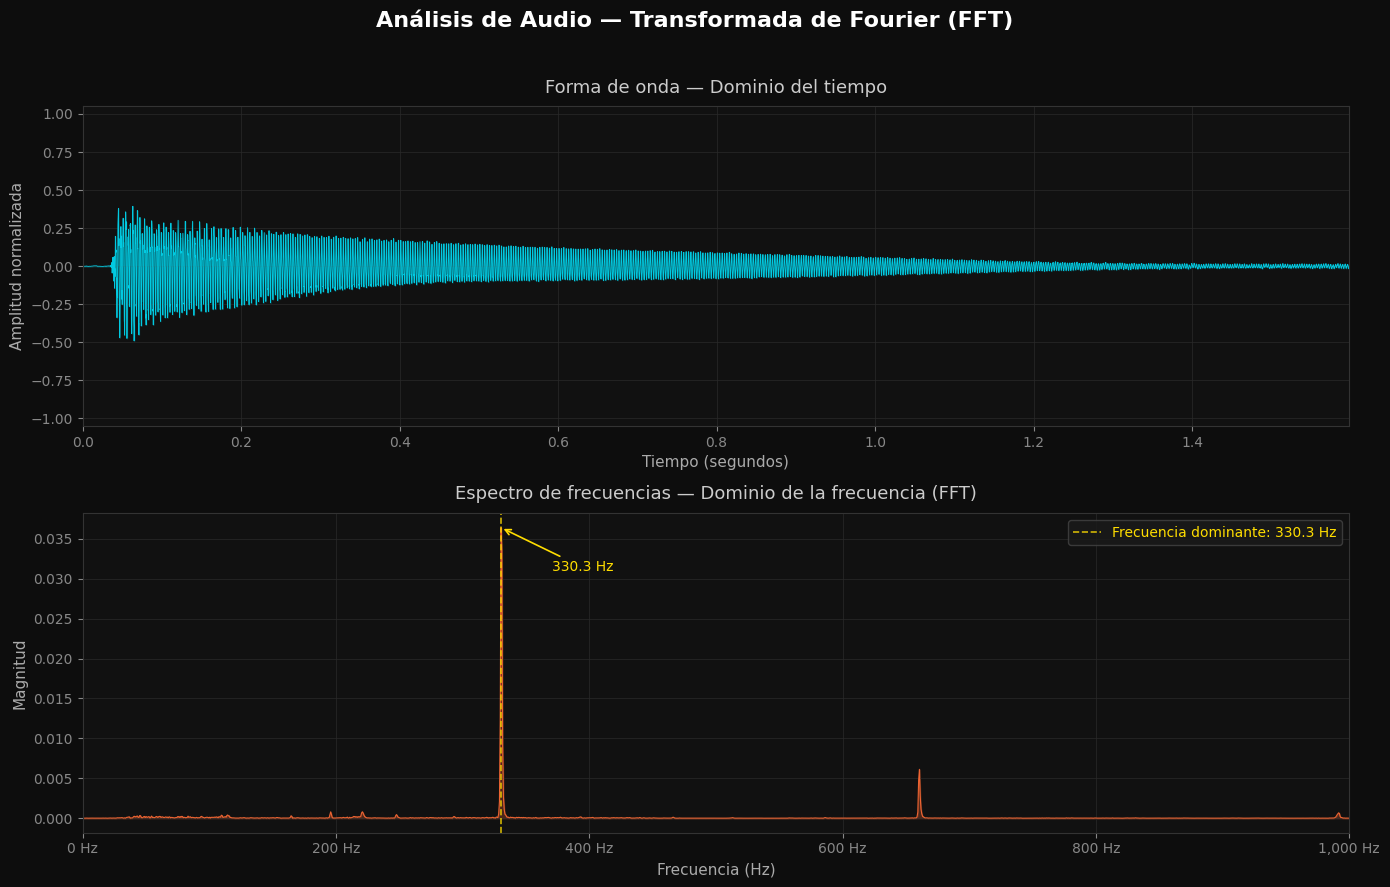

 Gráfica guardada como 'espectro_fourier.png'


In [13]:
%matplotlib inline

# Limitar la visualización al rango audible humano (20 Hz – 20,000 Hz)
freq_max_plot = min(1000, sample_rate / 2)
mask = frequencies <= freq_max_plot

# ── Configuración estética ─────────────────────────────────────────────────
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 1, figsize=(14, 9), facecolor='#0d0d0d')
fig.suptitle('Análisis de Audio — Transformada de Fourier (FFT)',
             fontsize=16, fontweight='bold', color='white', y=0.98)

# ── Gráfica 1: Señal en el tiempo ─────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#111111')

# Submuestreamos para no graficar millones de puntos
step = max(1, len(signal) // 10000)
ax1.plot(time_axis[::step], signal[::step],
         color='#00e5ff', linewidth=0.6, alpha=0.85)
ax1.fill_between(time_axis[::step], signal[::step],
                 alpha=0.15, color='#00e5ff')

ax1.set_title('Forma de onda — Dominio del tiempo', fontsize=13,
              color='#cccccc', pad=10)
ax1.set_xlabel('Tiempo (segundos)', color='#aaaaaa', fontsize=11)
ax1.set_ylabel('Amplitud normalizada', color='#aaaaaa', fontsize=11)
ax1.set_xlim([0, duration])
ax1.set_ylim([-1.05, 1.05])
ax1.tick_params(colors='#888888')
ax1.spines[:].set_color('#333333')
ax1.grid(True, color='#2a2a2a', linewidth=0.5)

# ── Gráfica 2: Espectro de frecuencias (FFT) ──────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#111111')

# Store the line object, and enable picker for hover detection
line2, = ax2.plot(frequencies[mask], magnitude[mask],
                 color='#ff6b35', linewidth=0.8, alpha=0.9) # Removed picker=True as it's not supported in inline backend
ax2.fill_between(frequencies[mask], magnitude[mask],
                 alpha=0.25, color='#ff6b35')

# Marcar la frecuencia dominante
ax2.axvline(x=freq_dom, color='#ffdd00', linewidth=1.2,
            linestyle='--', alpha=0.8,
            label=f'Frecuencia dominante: {freq_dom:.1f} Hz')
ax2.annotate(f'{freq_dom:.1f} Hz',
             xy=(freq_dom, mag_max),
             xytext=(freq_dom + freq_max_plot * 0.04, mag_max * 0.85),
             color='#ffdd00', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='#ffdd00', lw=1.2))

ax2.set_title('Espectro de frecuencias — Dominio de la frecuencia (FFT)',
              fontsize=13, color='#cccccc', pad=10)
ax2.set_xlabel('Frecuencia (Hz)', color='#aaaaaa', fontsize=11)
ax2.set_ylabel('Magnitud', color='#aaaaaa', fontsize=11)
ax2.set_xlim([0, freq_max_plot])
ax2.tick_params(colors='#888888')
ax2.spines[:].set_color('#333333')
ax2.grid(True, color='#2a2a2a', linewidth=0.5)
ax2.legend(facecolor='#1a1a1a', edgecolor='#444444',
           labelcolor='#ffdd00', fontsize=10)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,} Hz'))

# Removed interactive hover annotation code as it relies on interactive backend

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('espectro_fourier.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print(" Gráfica guardada como 'espectro_fourier.png'")

In [14]:
# ── Centroide espectral ────────────────────────────────────────────────────
# Es la media ponderada de las frecuencias, donde el peso es la magnitud
centroide = np.sum(frequencies * magnitude) / np.sum(magnitude)

# ── Top 5 frecuencias dominantes ──────────────────────────────────────────
top_indices = np.argsort(magnitude)[::-1][:5]
top_freqs   = frequencies[top_indices]
top_mags    = magnitude[top_indices]

# ── Energía por banda ─────────────────────────────────────────────────────
def energia_banda(f_min, f_max):
    """Calcula la energía total en un rango de frecuencias."""
    mask_b = (frequencies >= f_min) & (frequencies < f_max)
    return np.sum(magnitude[mask_b] ** 2)

e_bajos   = energia_banda(20, 300)
e_medios  = energia_banda(300, 4000)
e_agudos  = energia_banda(4000, 20000)
e_total   = e_bajos + e_medios + e_agudos

# ── Mostrar resultados ─────────────────────────────────────────────────────
print("═" * 52)
print("          RESUMEN DEL ANÁLISIS ESPECTRAL")
print("═" * 52)
print(f"  Tasa de muestreo  : {sample_rate:,} Hz")
print(f"  Duración          : {duration:.3f} s")
print(f"  Frecuencia dominante: {freq_dom:.2f} Hz")
print(f"  Centroide espectral : {centroide:.2f} Hz")
print()
print("  TOP 5 FRECUENCIAS:")
for i, (f, m) in enumerate(zip(top_freqs, top_mags), 1):
    print(f"    {i}. {f:>9.2f} Hz  │  magnitud: {m:.5f}")
print()
print("  ENERGÍA POR BANDA:")
print(f"    Bajos  (  20 – 300 Hz)  : {e_bajos/e_total*100:5.1f}%")
print(f"    Medios ( 300 – 4000 Hz) : {e_medios/e_total*100:5.1f}%")
print(f"    Agudos (4000 – 20000 Hz): {e_agudos/e_total*100:5.1f}%")
print("═" * 52)

════════════════════════════════════════════════════
          RESUMEN DEL ANÁLISIS ESPECTRAL
════════════════════════════════════════════════════
  Tasa de muestreo  : 48,000 Hz
  Duración          : 1.598 s
  Frecuencia dominante: 330.33 Hz
  Centroide espectral : 949.53 Hz

  TOP 5 FRECUENCIAS:
    1.    330.33 Hz  │  magnitud: 0.03640
    2.    330.96 Hz  │  magnitud: 0.03368
    3.    329.71 Hz  │  magnitud: 0.01259
    4.    331.58 Hz  │  magnitud: 0.00923
    5.    660.66 Hz  │  magnitud: 0.00612

  ENERGÍA POR BANDA:
    Bajos  (  20 – 300 Hz)  :   0.3%
    Medios ( 300 – 4000 Hz) :  99.7%
    Agudos (4000 – 20000 Hz):   0.0%
════════════════════════════════════════════════════


In [15]:
# Eliminar archivo WAV temporal
if os.path.exists(OUTPUT_WAV_TEMP):
    os.remove(OUTPUT_WAV_TEMP)
    print(f"  Archivo temporal '{OUTPUT_WAV_TEMP}' eliminado.")

print("\n Archivos generados:")
for fname in [OUTPUT_MP3_PATH, 'espectro_fourier.png']:
    if os.path.exists(fname):
        size_kb = os.path.getsize(fname) / 1024
        print(f"    {fname}  ({size_kb:.1f} KB)")

  Archivo temporal 'audio_temp.wav' eliminado.

 Archivos generados:
    Cuerda1_libre.mp3  (13.0 KB)
    espectro_fourier.png  (256.1 KB)
